# Gradient Decent

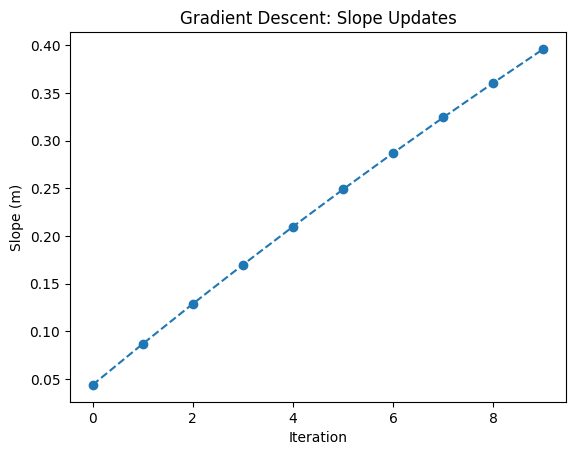

In [9]:
import numpy as np
import matplotlib.pyplot as plt
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 6, 8, 10])
m = 0
b = 0
iteration = 10
alpha = 0.001
m_values = []
n = len(x)  
for i in range(iteration):
    y_pred = m * x + b
    error = y - y_pred
    dm = (-2 / n) * np.sum(x * error)
    db = (-2 / n) * np.sum(error)
    m = m - alpha * dm
    b = b - alpha * db
    m_values.append(m)
plt.plot(m_values, marker='o', linestyle='--')
plt.xlabel('Iteration')
plt.ylabel('Slope (m)')
plt.title('Gradient Descent: Slope Updates')
plt.show()


# Machine Learning Model using - KNN

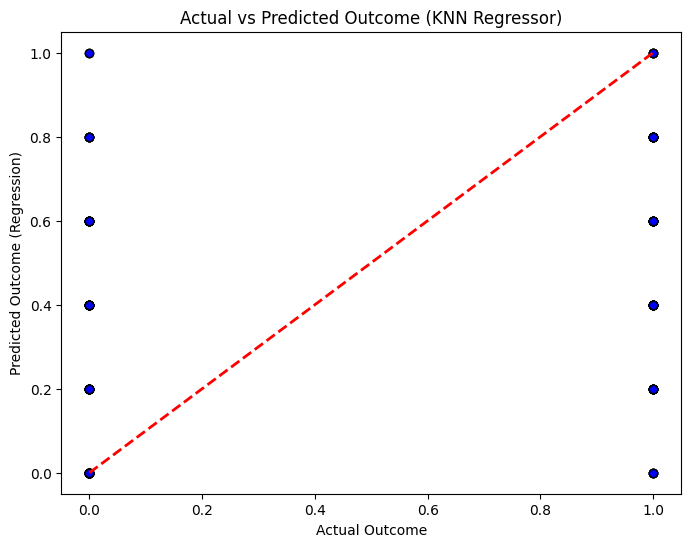

Enter the following details for prediction:


Pregnancies:  78
Glucose:  456
BloodPressure:  1012
SkinThickness:  7896
Insulin:  12365
BMI:  1596
DiabetesPedigreeFunction:  123654
Age:  82



--- Predictions ---
Regression Predicted Value: 0.8000
Regression Prediction: Diabetic
Classification Prediction: Diabetic

Nearest Neighbors (Regression):
Neighbor 1: Index=228, Outcome=1, Distance=367385.2878
Neighbor 2: Index=198, Outcome=0, Distance=367385.5601
Neighbor 3: Index=491, Outcome=1, Distance=367385.6836
Neighbor 4: Index=350, Outcome=1, Distance=367386.1303
Neighbor 5: Index=316, Outcome=1, Distance=367386.8571

Nearest Neighbors (Classification):
Neighbor 1: Index=228, Outcome=1, Distance=367385.2878
Neighbor 2: Index=198, Outcome=0, Distance=367385.5601
Neighbor 3: Index=491, Outcome=1, Distance=367385.6836
Neighbor 4: Index=350, Outcome=1, Distance=367386.1303
Neighbor 5: Index=316, Outcome=1, Distance=367386.8571


In [3]:
# using Diabetes 
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
import matplotlib.pyplot as plt
import numpy as np

data = pd.read_csv('diabetes.csv')

X = data.drop('Outcome', axis=1)
y = data['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

k = 5
knn_reg = KNeighborsRegressor(n_neighbors=k)
knn_reg.fit(X_train_scaled, y_train)

knn_clf = KNeighborsClassifier(n_neighbors=k)
knn_clf.fit(X_train_scaled, y_train)

y_pred_reg = knn_reg.predict(X_test_scaled)

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_reg, color='blue', edgecolor='k')
plt.plot([0,1], [0,1], 'r--', lw=2)  
plt.xlabel("Actual Outcome")
plt.ylabel("Predicted Outcome (Regression)")
plt.title("Actual vs Predicted Outcome (KNN Regressor)")
plt.show()

features = X.columns.tolist()
print("Enter the following details for prediction:")
user_values = {}
for feature in features:
    user_values[feature] = float(input(f"{feature}: "))

user_df = pd.DataFrame([user_values])
user_scaled = scaler.transform(user_df)

predicted_value_reg = knn_reg.predict(user_scaled)[0]
prediction_reg = "Diabetic" if predicted_value_reg >= 0.5 else "Non-Diabetic"

predicted_class = knn_clf.predict(user_scaled)[0]
prediction_class = "Diabetic" if predicted_class == 1 else "Non-Diabetic"

print(f"\n--- Predictions ---")
print(f"Regression Predicted Value: {predicted_value_reg:.4f}")
print(f"Regression Prediction: {prediction_reg}")
print(f"Classification Prediction: {prediction_class}")

distances, indices = knn_reg.kneighbors(user_scaled)
print("\nNearest Neighbors (Regression):")
for i, idx in enumerate(indices[0]):
    neighbor_label = y_train.iloc[idx]   
    print(f"Neighbor {i+1}: Index={idx}, Outcome={neighbor_label}, Distance={distances[0][i]:.4f}")

distances_clf, indices_clf = knn_clf.kneighbors(user_scaled)
print("\nNearest Neighbors (Classification):")
for i, idx in enumerate(indices_clf[0]):
    neighbor_label = y_train.iloc[idx]   
    print(f"Neighbor {i+1}: Index={idx}, Outcome={neighbor_label}, Distance={distances_clf[0][i]:.4f}")


Accuracy: 1.00
Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         3
      Medium       1.00      1.00      1.00         3

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6




Enter years of experience for salary category prediction:  12


Predicted Salary Category: High


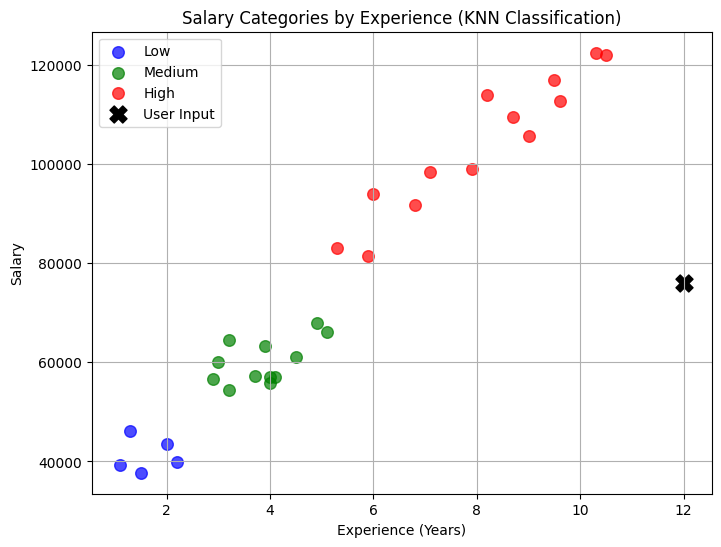

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

data = pd.read_csv('salary_data.csv')

def categorize_salary(s):
    if s < 50000:
        return 'Low'
    elif s <= 80000:
        return 'Medium'
    else:
        return 'High'

data['SalaryCategory'] = data['Salary'].apply(categorize_salary)

X = data[['Experience']]   
y = data['SalaryCategory']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

k = 3
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

experience = float(input("\nEnter years of experience for salary category prediction: "))

user_df = pd.DataFrame([[experience]], columns=['Experience'])
user_scaled = pd.DataFrame(scaler.transform(user_df), columns=['Experience'])

predicted_category = knn.predict(user_scaled)[0]
print(f"Predicted Salary Category: {predicted_category}")

plt.figure(figsize=(8, 6))

categories = ['Low', 'Medium', 'High']
colors = {'Low': 'blue', 'Medium': 'green', 'High': 'red'}

for cat in categories:
    subset = data[data['SalaryCategory'] == cat]
    plt.scatter(subset['Experience'], subset['Salary'],
                c=colors[cat], label=cat, s=70, alpha=0.7)

plt.scatter(experience, np.mean(data['Salary']),
            c='black', s=150, marker='X', label='User Input')

plt.title("Salary Categories by Experience (KNN Classification)")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary")
plt.legend()
plt.grid(True)
plt.show()
